# Supplementary File 3: Tissue Thickness Quantification
for ``Four-Fold Expansion Microscopy of Tissue"
by Corban Swain, Sapna Sinha, and Ed Boyden

## 1. Setting Up Repository and Opening the Notebook
1. You will need to install and set up the following software before continuing:
   - [ ] [**git** https://git-scm.com/](https://git-scm.com/)
   - [ ] [**mamba** https://mamba.readthedocs.io](https://mamba.readthedocs.io/en/latest/installation/mamba-installation.html)
   - [ ] [**Fiji (ImageJ)** https://imagej.net/software/fiji/downloads](https://imagej.net/software/fiji/downloads)
         (version 1.54p was used)
2. Clone the
   [**ExM-Demo-Figures** repository (https://github.com/CorbanSwain/ExM-Demo-Figures)](https://github.com/CorbanSwain/ExM-Demo-Figures)
   into a directory (e.g. `~/ExM-Demo-Figures`) on your computer. Then initialize and update the submodules.
   ```
   cd ~
   git clone https://github.com/CorbanSwain/ExM-Demo-Figures ~/ExM-Demo-Figures
   git submodule update --init
   ```
4. Set up the Python environment according to the environment configuration provided in the repository.
   ```
   cd ~/ExM-Demo-Figures/envs/
   mamba create -f exm-demo-fig-py3.12-env.yml
   ```
5. Then run JupyterLab and open this notebook via the JupyterLab interface.
   ```
   cd ~/ExM-Demo-Figures/source
   mamba activate exm-demo-fig-py3.12-env 
   jupyter lab supplementary_file_xx-thickness-analysis.ipynb
   ```

In [ ]:
### ?. Acquisition and export of images.

## ?. Analysis of Z-Stacks with Python
Run the following cells proces the images

### ?.1 Package Imports

In [5]:
# 3.1.1 base and metaprogramming imports
from __future__ import annotations
import os
import sys
import contextlib
from typing import Union, Any, Optional
import enum

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import tifffile

# 3.1.2 ipynb-specific imports
try:
    import ipynbname
except Exception as e:
    warnings.warn(f'`ipynbname` module import failed with error: {e!r}')
    ipynbname = None
    
if ipynbname is not None:
    _file = ipynbname.path()
else:
    # manually set the full path to the current notebook below if `ipynbname` 
    # import fails
    _file = ''

# 3.1.3 key path variables and management
source_dir = os.path.split(_file)[0]
repo_dir = os.path.abspath(os.path.join(source_dir, '..'))
data_dir = os.path.join(repo_dir, 'data')
figure_dir = os.path.join(repo_dir, 'figures')
if source_dir not in sys.path:
    sys.path.append(source_dir)

print('Imports done.')

Imports done.


### 3.2 Plotting Defaults

In [6]:
# 3.2.1 load custom fonts, if available
custom_fonts = [
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Black.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Bold.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Roman.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Oblique.otf']
for font_path in custom_fonts:
    if os.path.exists(font_path):
        print(f'Adding font: "{os.path.split(font_path)[-1]}" to mpl.')
        mpl.font_manager.fontManager.addfont(font_path)

# 3.2.2 set plotting style
sns.set_style(
    'ticks',
    {'font.sans-serif': [
        'Helvetica LT Pro', 'Helvetica', 'Arial', 'sans-serif'],
     'mathtext.fontset': ['cm',],
     'axes.linewidth': 2})

# 3.2.3 set axis and figure defaults
axes_lw = 1.25
mpl.rcParams['axes.linewidth'] = axes_lw
mpl.rcParams['xtick.major.width'] = axes_lw
mpl.rcParams['xtick.minor.width'] = axes_lw
mpl.rcParams['ytick.major.width'] = axes_lw
mpl.rcParams['ytick.minor.width'] = axes_lw

mpl.rcParams['axes.facecolor'] = 'none'

mpl.rcParams['figure.frameon'] = False
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['figure.edgecolor'] = 'none'

print('Plotting defaults set; done.')

Adding font: "Linotype - HelveticaLTPro-Black.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Bold.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Roman.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Oblique.otf" to mpl.
Plotting defaults set; done.


### 3.3 Filepaths and Other Parameter Inputs

In [7]:
# 3.3.1 filepath names
# Edit these fields to match the files you wish to analyze.
z_depth_dname = 'z-depth-analysis'
normal_fname = 'normal-nhs-z-stack.tif'
expanded_fname = 'expanded-nhs-z-stack.tif'

figure_name = 'z_depth_analysis'  # output figure name

MAG_KEY = 'magnification'
XY_PITCH_UM_KEY = 'xy_pitch_um'
Z_PITCH_UM_KEY = 'z_pitch_um'
normal_md = {
    MAG_KEY: 40,
    XY_PITCH_UM_KEY: 0.1696231,
    Z_PITCH_UM_KEY: 0.4}
expanded_md = {
    MAG_KEY: 20,
    XY_PITCH_UM_KEY: 0.3523270,
    Z_PITCH_UM_KEY: 2.5}

print('Parameters set; done.')

Parameters set; done.


In [29]:
class Dim(str, enum.Enum):
    X = 'x'
    Y = 'y'
    Z = 'z'

    @property
    def nd2_str(self):
        if self is Dimension.X:
            return 'x'
        elif self is Dimension.Y:
            return 'y'
        elif self is Dimension.Z:
            return 'z'

    @property
    def is_numeric(self):
        return self in (Dim.X, Dim.Y, Dim.Z)

    def __repr__(self):
        return f'Dim(\'{self:s}\')'

class CoordinateVector:
    # magic methods
    def __init__(self,
                 vector: np.ndarray,
                 unit: Optional[str] = None):
        self.vector: np.ndarray = vector
        self.unit: Optional[str] = unit

    def __eq__(self, other: CoordinateVector):
        if not isinstance(other, CoordinateVector):
            return False

        if not (len(self.vector) == len(other.vector)):
            return False

        if not (self.unit == other.unit):
            return False

        return all(si == oi for si, oi in zip(self.vector, other.vector))

    def __repr__(self):
        return (f'Coord([{self.vector[0]}, ...], ' 
                f'len={len(self.vector):d}, unit=\'{self.unit}\')')

    # class methods
    @classmethod
    def from_pitch_and_len(cls,
                           pitch: float,
                           length: int, 
                           unit: Optional[str] = None,
                           zero_center: bool = False):
        adj = ((float(length) / 2) - 0.5) if zero_center else 0
        vector = (np.arange(length) + adj) * pitch
        return cls(vector, unit=unit)
        

    # properties
    @property
    def median_pitch(self):
        return np.median(np.diff(self.vector))

    # general methods
    def flip(self, in_place: bool = False):
        if in_place:
            self.vector = np.flip(self.vector, axis=0)
        else:
            new_cv = self.__class__(np.flip(self.vector, axis=0),
                                    unit=self.unit)
            return new_cv

class TiffKeys:
    BITS_PER_SAMPLE = 'BitsPerSample'

class TIFFDataset(object):
    """
    Helper class for working with .tiff image files
    """
    # magic methods
    def __init__(self,
                 path: str | bytes | os.PathLike[Any],
                 name: str,
                 xy_pitch: float,
                 z_pitch: float,
                 pitch_unit: str,
                 dimensions: tuple[Dim, ...]
                 ):

        self.path = path
        self.name = name
        self.xy_pitch = xy_pitch
        self.z_pitch = z_pitch
        self.pitch_unit = pitch_unit
        self.dimensions = dimensions

        # set by other initializers
        self.bits_per_sample: Optional[int] = None
        self.coordinates: Optional[dict[Dim, CoordinateVector]] = None
        self._metadata: tifffile.TiffTags
        self._init_from_tifffile()

        assert len(self.dimensions) == self.ndim, \
            ('dimensions must be a tuple with length equal to '
             'the number of dimensions in the image data')

    def __repr__(self):
        return (
            f'{self.__class__.__name__:s}(path="{self.path}",'
            f' name="{self.name}")')

    def __str__(self):
        return (
            f'{self.__class__.__name__:s}(name="{self.name}")'
            f' with shape {self.shape}')

    # methods
    def generate_coordinates(self,
                             zero_center: bool | dict[Dim, bool] = False) -> None:
        coordinates = {}
        for i, dim in enumerate(self.dimensions):
            if dim in (Dim.X, Dim.Y):
                pitch_um = self.xy_pitch
            if dim is Dim.Z:
                pitch_um = self.z_pitch
            # check if zero_center is a dict
            if isinstance(zero_center, dict):
                zc = zero_center.get(dim, False)
            coordinates[dim] = CoordinateVector.from_pitch_and_len(
                pitch_um,
                self.shape[i],
                unit='micron',
                zero_center=zc)
        self.coordinates = coordinates
    
    # properties
    @property
    def ndim(self) -> int:
        return self.image_ndarray.ndim

    @property
    def shape(self) -> tuple[int, ...]:
        return self.image_ndarray.shape

    @property
    def image_ndarray(self) -> np.ndarray:
        """
        ndarray of the image data
        """
        return self._image_ndarray

    @property
    def metadata(self) -> tifffile.TiffTags:
        """
        metadata from tiff file as tifffile.TiffTags
        """
        return self._metadata

    # protected methods
    @contextlib.contextmanager
    def _tifffile(self) -> tifffile.TiffFile:
        """
        wrapper for tifffile.TiffFile context using the object's path
        """
        with tifffile.TiffFile(self.path) as tif:
            yield tif

    def _init_from_tifffile(self) -> None:
        """
        initializes the object attributes from a .tiff file on disk
        """
        self._load_image_data()
        with self._tifffile() as tif:
            self._metadata = tif.pages[0].tags
            self.bits_per_sample = (
                    self.metadata[TiffKeys.BITS_PER_SAMPLE].value)

    def _load_image_data(self) -> None:
        """
        loads image data from the tifffile into an ndarray attribute of the
        object.
        """
        print(f'Loading all image data from tiff file at "{self.path:s}".')
        with self._tifffile() as tif:
            self._image_ndarray = tif.asarray()

print('Helper classes loaded; done.')

Helper classes loaded; done.


### 3.4 Loading and Processing Data Tables

In [30]:
# 3.4.1 generate full paths to files
z_depth_dir = os.path.join(data_dir, z_depth_dname)
normal_tif_path = os.path.join(z_depth_dir, normal_fname)
expanded_tif_path = os.path.join(z_depth_dir, expanded_fname)
print('Set full paths')

Set full paths


In [31]:
normal_dset = TIFFDataset(
    normal_tif_path,
    name='Normal',
    xy_pitch=normal_md[XY_PITCH_UM_KEY],
    z_pitch=normal_md[Z_PITCH_UM_KEY],
    pitch_unit='micron',
    dimensions=(Dim.Z, Dim.Y, Dim.X))
normal_dset.generate_coordinates(zero_center={Dim.X: True, Dim.Y: True})
print(f'normal_dset : {normal_dset}')
print(f'   normal_dset.coordinates : {normal_dset.coordinates}')

expanded_dset = TIFFDataset(
    expanded_tif_path,
    name='Expanded',
    xy_pitch=expanded_md[XY_PITCH_UM_KEY],
    z_pitch=expanded_md[Z_PITCH_UM_KEY],
    pitch_unit='micron',
    dimensions=(Dim.Z, Dim.Y, Dim.X))
expanded_dset.generate_coordinates(zero_center={Dim.X: True, Dim.Y: True})
print(f'expanded_dset : {expanded_dset}')
print(f'  expanded_dset.coordinates : {expanded_dset.coordinates}')

Loading all image data from tiff file at "I:\CorbanSwain\repos\exm-demo-figures\data\z-depth-analysis\normal-nhs-z-stack.tif".
normal_dset : TIFFDataset(name="Normal") with shape (278, 2048, 2048)
   normal_dset.coordinates : {Dim('Dim.Z'): Coord([0.0, ...], len=278, unit='micron'), Dim('Dim.Y'): Coord([173.60924285, ...], len=2048, unit='micron'), Dim('Dim.X'): Coord([173.60924285, ...], len=2048, unit='micron')}
Loading all image data from tiff file at "I:\CorbanSwain\repos\exm-demo-figures\data\z-depth-analysis\expanded-nhs-z-stack.tif".
expanded_dset : TIFFDataset(name="Expanded") with shape (127, 2048, 2048)
  expanded_dset.coordinates : {Dim('Dim.Z'): Coord([0.0, ...], len=127, unit='micron'), Dim('Dim.Y'): Coord([360.60668450000003, ...], len=2048, unit='micron'), Dim('Dim.X'): Coord([360.60668450000003, ...], len=2048, unit='micron')}


### 3.5 Show ROI Delete List
This is a tool to print the regions that were removed from the original ROI Manager at step 2.12 above.

In [5]:
# 3.5.1 helper function for printing a list as columns
def print_list_in_columns(data, num_columns=10, column_padding=2):
    # function partially generated by Gemeni AI, prompted by Corban Swain
    max_len = max(len(str(item)) for item in data) if data else 0
    col_width = max_len + column_padding
    for i, item in enumerate(data):
        print(str(item).ljust(col_width), end="")
        if (i + 1) % num_columns == 0:
            print()
    if len(data) % num_columns != 0:
        print()  # Print a final newline if the list doesn't perfectly fill the 
                 # last row

# 3.5.2 helper function for computing and printing the deleted regions
def print_delete_list(good_list, raw_df, name):
    good_len = len(good_list)
    total_len = len(raw_df)
    bad_len = total_len - good_len
    print(f'\nLabels of deleted ROIs for {name} dataset:')
    print(f'({good_len:d} regions kept;'
          f' {bad_len:d} regions deleted)')
    if bad_len == 0:
        print('none')
        return        
    print_list_in_columns(
        [(i+1) for i in range(total_len) if (i+1) not in good_list])

# 3.5.2 printing the delete list for each sample
print_delete_list(good_roi_normal_list, raw_normal_df, 'NORMAL')
print_delete_list(good_roi_exm_a_list, raw_exm_a_df, 'EXPANDED-A')
print_delete_list(good_roi_exm_b_list, raw_exm_b_df, 'EXPANDED-B')

print('\nDelete lists printed; done.')


Labels of deleted ROIs for NORMAL dataset:
(148 regions kept; 149 regions deleted)
1    2    3    4    5    6    7    8    10   11   
12   14   16   18   22   23   24   25   27   32   
33   34   42   50   52   53   56   62   64   66   
67   71   72   73   74   77   80   88   89   91   
93   95   97   98   100  101  102  107  108  110  
121  122  123  125  126  127  129  130  131  132  
133  135  136  139  140  141  146  147  149  151  
157  158  159  160  161  162  165  167  168  169  
171  172  175  179  182  183  185  187  195  196  
197  203  205  206  208  210  211  216  217  218  
223  226  227  229  230  232  233  238  239  240  
244  245  248  250  251  253  255  256  257  258  
259  261  262  263  266  269  271  272  273  274  
275  276  277  278  279  282  283  284  285  286  
289  290  291  292  293  294  295  296  297  

Labels of deleted ROIs for EXPANDED-A dataset:
(26 regions kept; 1 regions deleted)
1  

Labels of deleted ROIs for EXPANDED-B dataset:
(28 regions kept; 0

### 3.6 Compute Median Nuclei Sizes and *n*

In [6]:
# 3.6.1 create a pivot table computing the median sqrt area for each category
pivot = nuc_size_df.pivot_table(
    columns=category_key,
    values=sqrt_area_key,
    aggfunc='median',
    observed=True)

# 3.6.2 create pivot table counting the number of nuclei for each category
exm_median = pivot[expanded_cat_name].item()
unexm_median = pivot[unexpanded_cat_name].item()
ex_factor = exm_median / unexm_median

count_pivot = nuc_size_df.pivot_table(
    columns=category_key,
    values=sqrt_area_key,
    aggfunc='count',
    observed=True)
count_pivot = count_pivot.rename(index={sqrt_area_key: 'n'})

exm_n = count_pivot[expanded_cat_name].item()
unexm_n = count_pivot[unexpanded_cat_name].item()

print('Median [Area]^(1/2):')
print(pivot)
print()
print('Num Data Points:')
print(count_pivot)
print()
print(f'Expansion Factor: {ex_factor:.1f}x')
print('\nData summaries generated; done.')

Median [Area]^(1/2):
category      expanded    normal
[Area]^(1/2)  34.59245  8.826096

Num Data Points:
category  expanded  normal
n               54     148

Expansion Factor: 3.9x

Data summaries generated; done.


### 3.7 Create and Save Figure

Figure generated and saved; done.


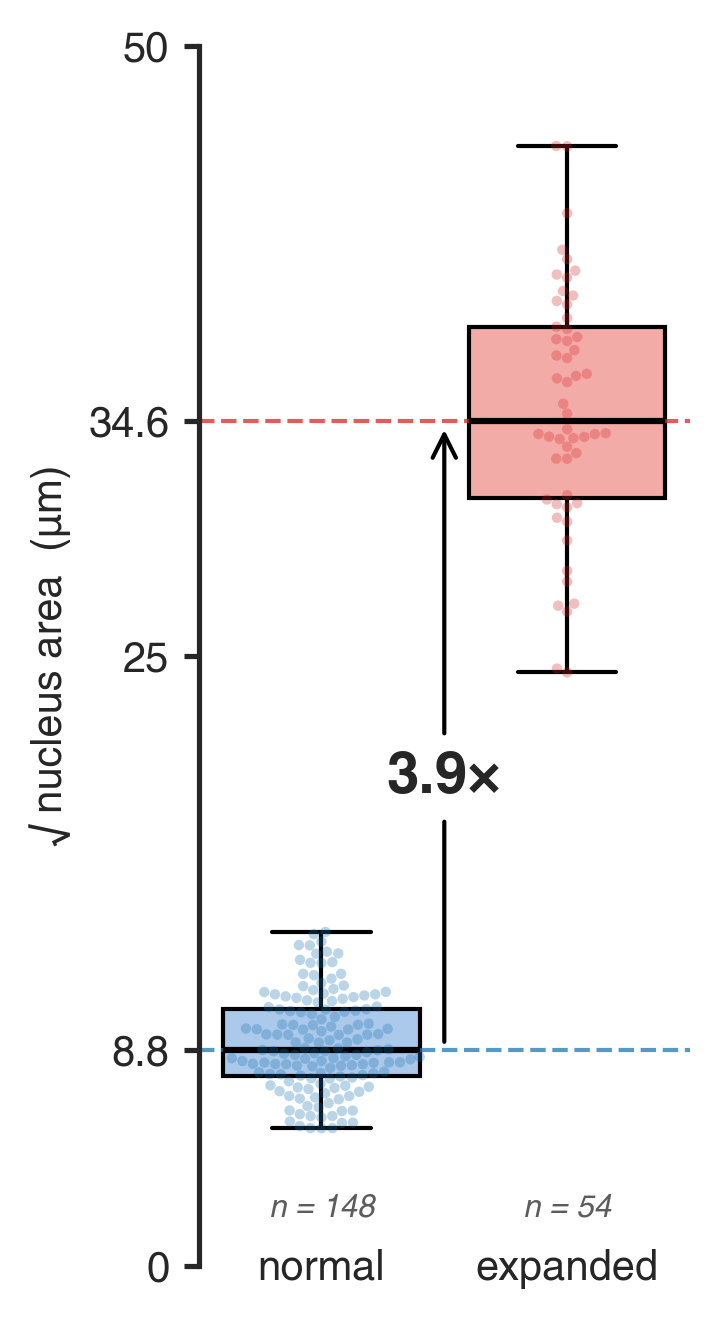

In [7]:
# 3.7.1 generate main figure object
fig = plt.figure(
    figsize=(2.5, 4.5),
    dpi=300)

# 3.7.2 set color palettes
palette_p = sns.color_palette(
    [sns.color_palette('pastel')[0],
     sns.color_palette('pastel')[3]])
palette_n = sns.color_palette(
    [sns.color_palette()[0],
     sns.color_palette()[3]])

# 3.7.3 use seaborn to plot boxplots with overlaid swarmplots from data
ax = sns.boxplot(
    data=nuc_size_df,
    x=category_key,
    y=sqrt_area_key,
    hue=category_key,
    palette=palette_p,
    order=[unexpanded_cat_name, expanded_cat_name],
    hue_order=[unexpanded_cat_name, expanded_cat_name],
    linecolor='k',
    medianprops={'lw': 1.5})
sns.swarmplot(
    data=nuc_size_df,
    x=category_key,
    y=sqrt_area_key,
    hue=category_key,
    size=2.5,
    alpha=0.3,
    ax=ax,
    palette=palette_n,
    color='k',
    order=[unexpanded_cat_name, expanded_cat_name],
    hue_order=[unexpanded_cat_name, expanded_cat_name])

# 3.7.4 plot horizontal lines at the category medians
ax.axhline(
    y=unexm_median,
    color=palette_n[0],
    ls='--',
    lw=1,
    alpha=0.75
)
ax.axhline(
    y=exm_median,
    color=palette_n[1],
    ls='--',
    lw=1,
    alpha=0.75
)

# 3.7.5 format look of axes
sns.despine(right=True, bottom=True, top=True)
ax.set_ylim(0, 50)
ax.spines['bottom'].set_bounds(0, 1)
ax.set_yticks(
    [0, 
     unexm_median,
     25,
     exm_median,
     50])
ax.set_yticklabels(
    ['0',
     f'{unexm_median:.1f}',
     '25',
     f'{exm_median:.1f}',
    '50'])
ax.set_ylabel('\u221A nucleus area  (\u00b5m)')
ax.set_xlabel(None)
ax.tick_params(axis='x', length=0, pad=-4)

# 3.7.6 annotate expansion factor
ax.annotate(
    f'{ex_factor:.1f}\u00D7',
    xy=(0.5, exm_median),
    xytext=(0.5, 20.0),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
    ),
    annotation_clip=False,
    ha='center',
    va='center',
    size=14,
    weight='bold',
)
ax.annotate(
    f'{ex_factor:.1f}\u00D7',
    xy=(0.5, unexm_median),
    xytext=(0.5, 20.0),
    arrowprops=dict(
        arrowstyle='-',
        color='black',
    ),
    annotation_clip=False,
    ha='center',
    va='center',
    alpha=0,
    size=14,
    weight='bold',
)

# 3.7.8 annotate num data points
ax.text(
    0, 2, 
    f'n = {unexm_n}',
    ha='center',
    va='baseline',
    size=7.5,
    style='oblique',
    alpha=0.75)
ax.text(
    1, 2, 
    f'n = {exm_n}',
    ha='center',
    va='baseline',
    size=7.5,
    style='oblique',
    alpha=0.75)

# 3.7.9 helper function for saving figure to pdf
def save_figures(
    filename=None, 
    figs=None, 
    dpi=200, 
    fmt='pdf', 
    directory=None,
    add_filename_timestamp=True, 
    stamp_kwargs=None):
    from matplotlib.backends.backend_pdf import PdfPages

    if filename is None:
        filename = 'all_figures'

    if add_filename_timestamp:
        filename = filename + '_' + time.strftime('%y%m%d-%H%M')

    if figs is None:
        figs = [plt.figure(n) for n in plt.get_fignums()]
    else:
        try:
            _ = iter(figs)
        except TypeError:
            figs = [figs, ]

    if stamp_kwargs:
        [stamp_fig(fig, **stamp_kwargs) for fig in figs]

    directory = 'figures' if directory is None else directory
    try:
        os.mkdir(directory)
    except FileExistsError:
        pass

    file_path = os.path.join(directory, filename)
    if fmt == 'pdf':
        file_path += '.pdf'
        with PdfPages(file_path) as pp:
            for fig in figs:
                fig.savefig(pp, format='pdf', dpi=dpi)
    else:
        for i, fig in enumerate(figs):
            fig.savefig('%s_%d.%s' % (file_path, i, fmt), format=fmt, dpi=dpi)

# 3.7.10 perform final layout of plot
plt.tight_layout()

# 3.7.11 export figure to pdf
save_figures(
    filename=figure_name,
    add_filename_timestamp=False,
    directory=figure_dir)

print('Figure generated and saved; done.')

## 4 Notebook Conversion 
This notebook can be converted to a `.pdf` via the following [**pandoc** (https://pandoc.org/)](https://pandoc.org/) 
command:

*for Unix-style command line:*
```bash
pandoc -o "supplementary_file_03-nuc-area.pdf" \  
    --pdf-engine=xelatex --highlight-style tango \
    -V geometry:landscape \
    -V geometry:top=0.75in,bottom=0.75in,left=1in,right=2in
    supplementary_file_03-nuc-area.ipynb
```

*for Windows Command Prompt:*
```
pandoc -o "supplementary_file_03-nuc-area.pdf" ^
    --pdf-engine=xelatex --highlight-style tango ^
    -V geometry:landscape ^
    -V geometry:top=0.75in,bottom=0.75in,left=1in,right=2in ^
    supplementary_file_03-nuc-area.ipynb
    
```